$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 2.1

## 理论

考虑一维测试函数

$$
h(x)=\frac{\sin(10\pi x)}{1 + 64(x - 0.25)^2} + x^2,\quad x\in[0,1]\tag{2.1}
$$

我们假定实验人员不知道该函数的具体形式，仅能够获取部分数据。设通过开展 $n=10$ 次实验生成数据，实验采样方案为区间 $[0,1]$ 上等间隔选取 10 个采样点。图 2.1 左图绘制了该测试函数（黑色虚线）以及数据集 $\{(x_i, y_i)\}_{i=1}^{10}$（蓝色圆点）。

我们可以使用 $(n-1)$ 次多项式对 $n$ 个数据点进行插值：

$$
y = \beta_0 + \beta_1x + \dots + \beta_{n-1}x^{n-1}
\tag{2.2}
$$

将式 (2.2) 中的多项式改写为

$$
y = \beta_0R_0(x) + \beta_1R_1(x) + \dots + \beta_{n-1}R_{n-1}(x)
\tag{2.3}
$$

其中 $R_i(x)$ 为 $i$ 次多项式，且规定 $R_0(x):=1$。例如，当 $x\in[-1,1]$ 时，可选取切比雪夫多项式：$R_1(x)=x$，$R_2(x)=2x^2-1$，$R_3(x)=4x^3-3x$，以此类推。切比雪夫多项式还有另一种表达形式：$R_i(x) = \cos\left(i\cos^{-1}(x)\right)$。接下来，为实现插值，需满足

$$
\sum_{j=0}^{n-1}\beta_jR_j(x_i) = y_i,\quad i=1,\dots,n
$$

采用矩阵记号，该方程组可写作

$$
\boldsymbol{R}\boldsymbol{\beta} = \boldsymbol{y}
$$

式中 $\boldsymbol{\beta} = (\beta_0,\dots,\beta_{n-1})'$，$\boldsymbol{y} = (y_1,\dots,y_n)'$；$\boldsymbol{R}$ 为 $n\times n$ 矩阵，其第 $i$ 行第 $j$ 列元素为 $R_j(x_i)$。

若 $\boldsymbol{R}$ 为非奇异矩阵，则可求得唯一解

$$
\hat{\boldsymbol{\beta}} = \boldsymbol{R}^{-1}\boldsymbol{y}
$$

由此得到多项式插值函数 $\hat{y}(x) = \boldsymbol{r}(x)'\hat{\boldsymbol{\beta}}$，其中 $\boldsymbol{r}(x) = (R_0(x), \dots, R_{n-1}(x))'$。因此，

$$
\hat{y}(x) = \boldsymbol{r}(x)'\boldsymbol{R}^{-1}\boldsymbol{y}
\tag{2.4}
$$

该插值函数在图 2.1 中以绿色实线绘制，但拟合函数出现了龙格现象。

我们可以通过优化拟合多项式的误差来克服龙格现象。设 $h_{n-1}(x)$ 为 $(n-1)$ 次多项式，对区间 $x_i\in[-1,1] \ (i=1,\dots,n)$ 上的数据 $\{(x_i, h(x_i))\}_{i=1}^n$ 进行插值。若 $h(x)$ 至少存在 $n$ 阶可导，回忆厄米特插值法的误差可知，此时一阶插值的误差为：

$$
h(x) - h_{n-1}(x) = \frac{h^{(n)}(\xi)}{n!}\prod_{i=1}^n (x-x_i)
$$

其中存在 $\xi\in[-1,1]$，$h^{(n)}(x)$ 代表 $h(x)$ 的 $n$ 阶导数。由此可以得到绝对误差上界：

$$
|h(x)-h_{n-1}(x)| \le \frac{1}{n!}\max_{\xi}\left|h^{(n)}(\xi)\right|\left|\prod_{i=1}^n (x-x_i)\right|
$$

不等式右侧的 $\frac{1}{n!}\max_{\xi}|h^{(n)}(\xi)|$ 由 $h(x)$ 决定，我们仅能优化 $|\prod_{i=1}^n(x-x_i)|$。依据等震荡定理，首一多项式 $p$ 能最小化 $\max_{x\in[-1,1]}|p(x)|$ 当且仅当其在 $[-1,1]$ 内的 $n+1$ 个点上等幅交替取值 $M$，其中 $M$ 为 $|p|$ 的最小最大值。反证，若 $M'$ 仍不是最小，则总能通过正负交替点间略加修正来令最大的 $M'$ 更小，直到所有的极大值都相等，此为最小的最大值 $M$。现在关注切比雪夫多项式 $R_i(x) = \cos(i\cos^{-1}(x))$，显然 $R_i(x)\in[-1,1]$，当 $x_k=\cos\frac{k\pi}{n}$ 时，$R_{i}(x_k)=\pm1$ 恰满足等震荡定理，因此切比雪夫多项式能够使所有 $n$ 次多项式的最大绝对值最小化。

因此，令 

$$
\prod_{i=1}^n (x-x_i) = \frac{1}{2^{n-1}}\cos\left(n\cos^{-1}(x)\right)
$$

即可最小化绝对误差上界，式中分母引入缩放常数 $2^{n-1}$（归纳易得）来保证右侧也是首一多项式。因此节点 $x_i$ 应当取切比雪夫多项式的零点（也称切比雪夫节点）。通过求解方程

$$
\cos\left(n\cos^{-1}(x_i)\right)=0
$$

可得节点表达式：

$$
x_i=\cos\left(\frac{\pi(i-0.5)}{n}\right),\quad i=1,\dots,n
\tag{2.5}
$$

图 2.1 右侧面板绘制了采用切比雪夫节点得到的 10 个试验设计点及其对应的函数求值结果（节点通过变换 $x \leftarrow (x + 1)/2$ 由区间 $[-1,1]$ 缩放至区间 $[0,1]$）。可以观察到，相较于等距设计点，这类设计点更多向区间两端边界聚集。图中同时以绿色实线给出插值函数，该插值函数能够较好逼近真实函数，相比左侧面板中的前一种插值方案实现了显著改进。

## 实践

创建画布宽 20 英寸、高 10 英寸，并将画布分为 1x2。依据公式

$$
h(x)=\frac{\sin(10\pi x)}{1 + 64(x - 0.25)^2} + x^2,\quad x\in[0,1]
$$

创建函数 f(x)。在区间 $[0,1]$ 上等间隔选取 301 个点作为作图的自变量，令其为 test，并计算其对应的函数值作为真实值，令其为 true。

绘制真实函数的图像，其中类型为 l，x 轴标注为 x，y 轴标注为 y，大小为 2，线宽为 4，线型为 2，y 轴范围为 c(min(true)-.25,max(true)+.25) 大小为 2，主标题为“等距节点多项式插值”，大小为 3。令 n=10，令 n=10，依据均匀区间端点公式

$$
D=\left\{\frac{i-1}{n-1}\right\}_{i=1}^{n}
$$

取 1:n 上的等距 n 个点作为观测点的横坐标，命名为 D。计算 D 上的函数值作为观测值，令其为 y。叠加观测值点，其中点型为 16，大小为 3，颜色为蓝色。导入 R 包 precma，使用 ployfit() 函数进行多项式拟合，拟合阶数为 n-1，再使用 polyval() 函数计算 test 上的预测值，令其为 yhat。绘制预测值曲线，其中颜色为 3，线宽为 4。添加图例，位置为 (.25,-.35)，图例内容为“真实值”和“预测值”，线型分别为 2 和 1，颜色分别为 1 和 3，线宽分别为 2 和 3，边框类型为 n，大小为 2。

绘制真实函数的图像，其中类型为 l，x 轴标注为 x，y 轴标注为 y，大小为 2，线宽为 4，线型为 2，y 轴范围为 c(min(true)-.25,max(true)+.25) 大小为 2，主标题为“切比雪夫节点多项式插值”，大小为 3。依据切比雪夫节点公式

$$
x_i=\cos\left(\frac{\pi(i-0.5)}{n}\right),\quad i=1,\dots,n
$$

在 $[-1,1]$ 上生成 n 个切比雪夫节点，令其为 d。将 d 由区间 $[-1,1]$ 缩放至区间 $[0,1]$，令其为 D。计算 D 上的函数值作为观测值，令其为 y。叠加观测值点，其中点型为 16，大小为 3，颜色为蓝色。使用 ployfit() 函数进行多项式拟合，拟合阶数为 n-1，再使用 polyval() 函数计算 test 上的预测值，令其为 yhat。绘制预测值曲线，其中颜色为 3，线宽为 4。添加图例，位置为 (.25,-.35)，图例内容为“真实值”和“预测值”，线型分别为 2 和 1，颜色分别为 1 和 3，线宽分别为 2 和 3，边框类型为 n，大小为 2。

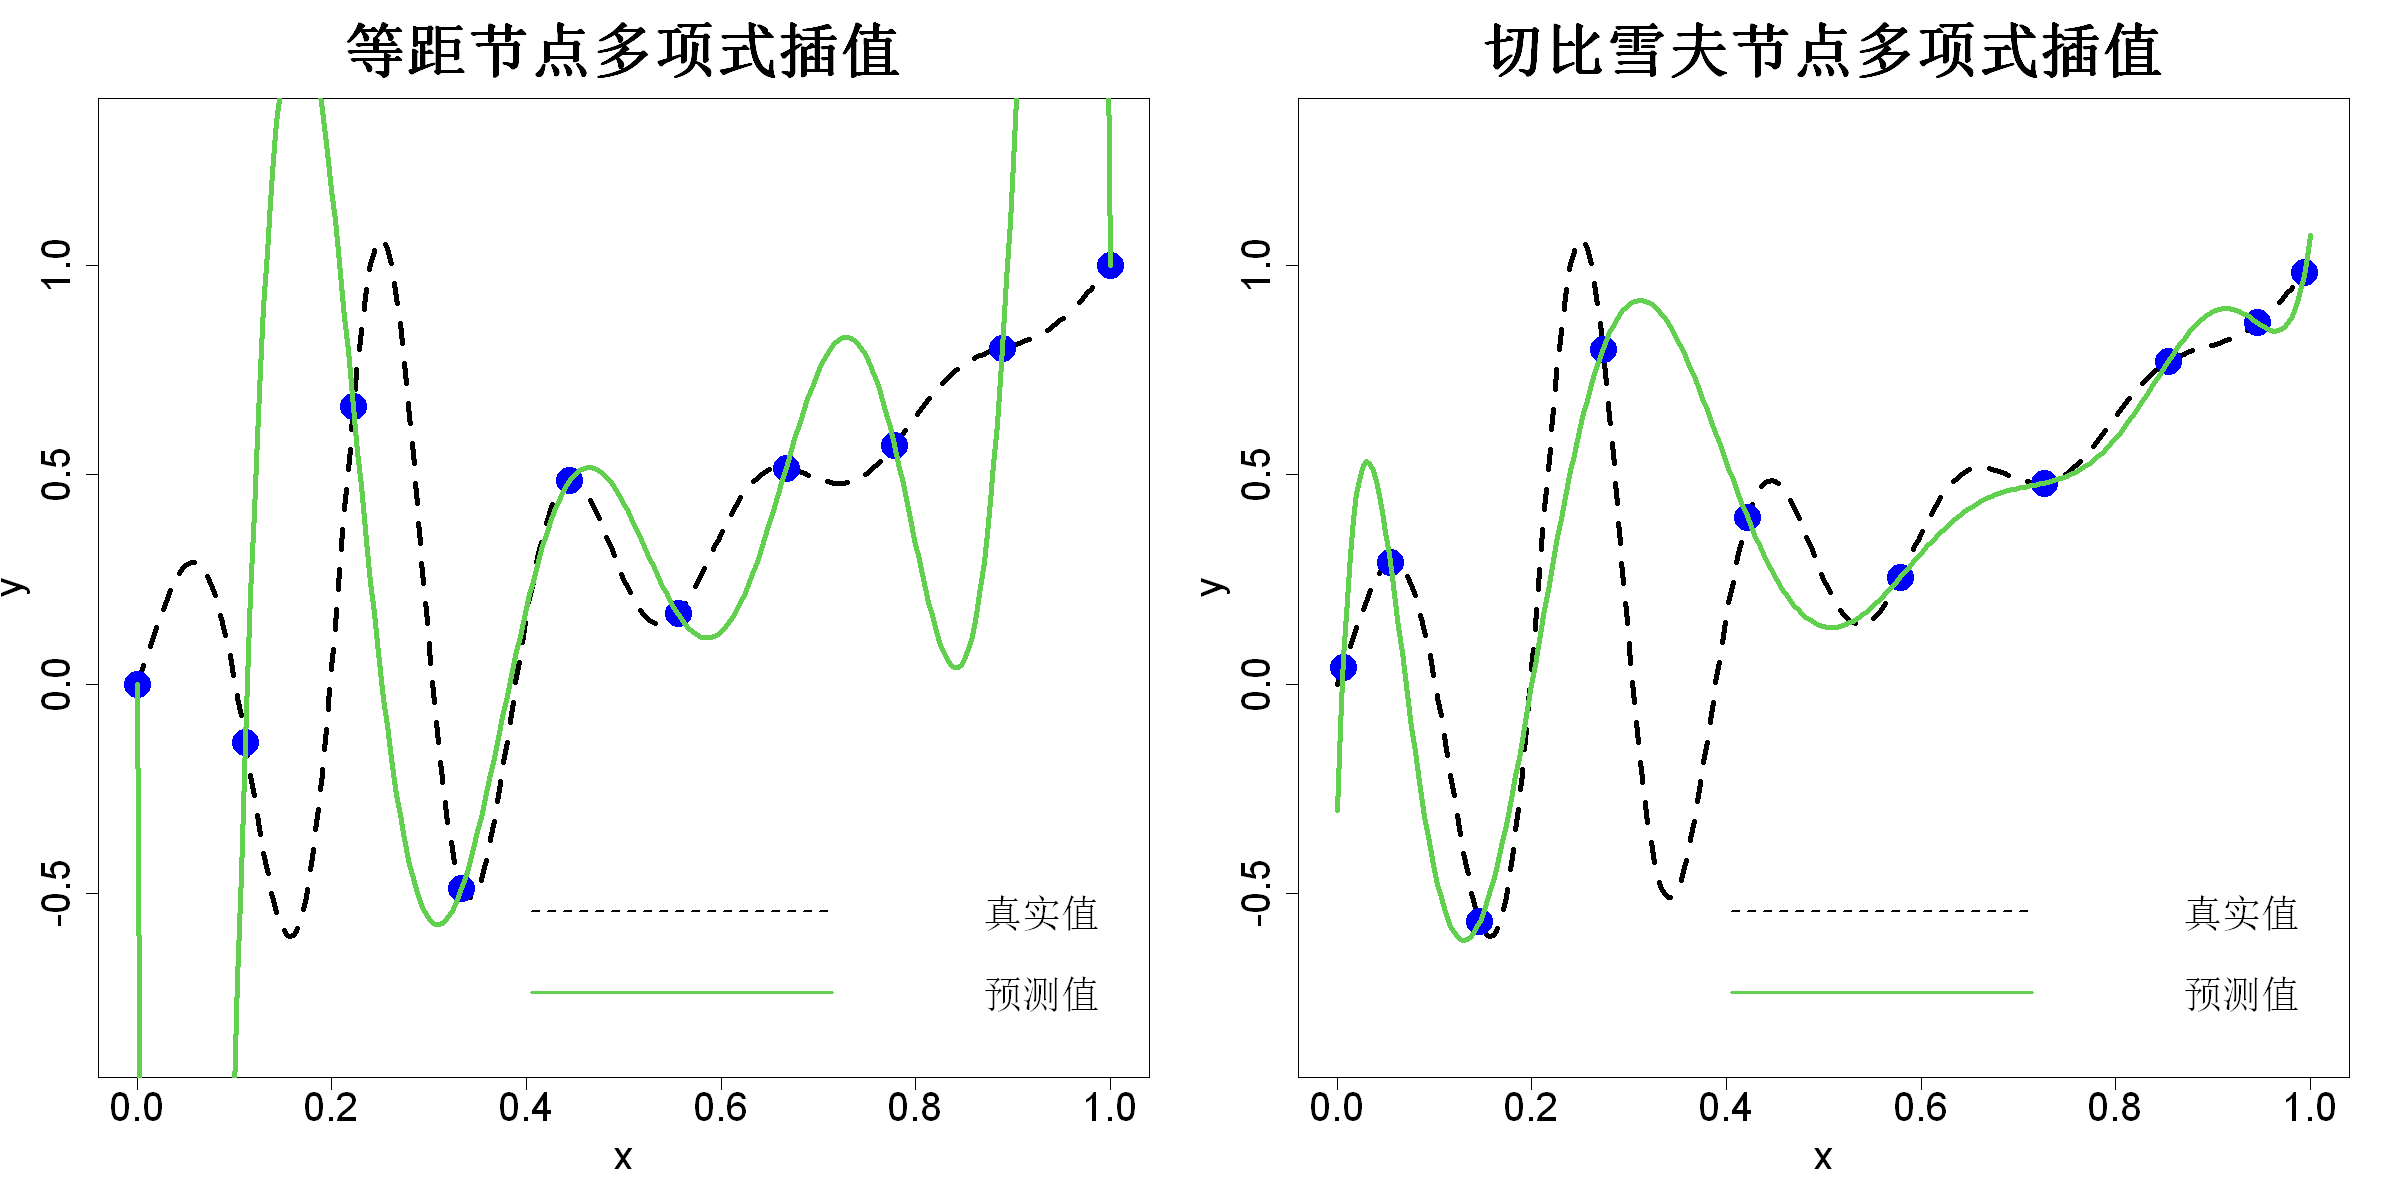

In [ ]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)

plot(test,true,type="l",xlab="x",ylab="y",lwd=4,lty=2,ylim=c(min(true)-.25,max(true)+.25),main="等距节点多项式插值",cex.main=3,cex.lab=2,cex.axis=2)
n=10
D=((1:n)-1)/(n-1)
y=f(D)
points(D,y,pch=16,cex=3,col="blue")
library(pracma)
yhat=polyfit(D,y,n-1)|>
polyval(test)
lines(test,yhat,col=3,lwd=4)
legend(.25,-.35,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(2,3),bty="n",cex=2)

plot(test,true,type="l",xlab="x",ylab="y",lwd=4,lty=2,col=1,ylim=c(min(true)-.25,max(true)+.25),main="切比雪夫节点多项式插值",cex.main=3,cex.lab=2,cex.axis=2)
d=cos(pi*((1:n)-.5)/n)
D=(d+1)/2
y=f(D)
points(D,y,pch=16,cex=3,col="blue")
yhat=polyfit(D,y,n-1)|>
polyval(test)
lines(test,yhat,col=3,lwd=4)
legend(.25,-.35,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(2,3),bty="n",cex=2)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$